# Exploratory Data Analysis
Use this notebook for initial data exploration of the traffic data.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style="whitegrid")

## Load Data

In [8]:
# 1. Loading datasets
print("Loading datasets...")
try:
    train = pd.read_csv('../data/raw/train.csv')
    test = pd.read_csv('../data/raw/test.csv')
    sample_sub = pd.read_csv('../data/raw/sample_submission.csv')
    print(f"Train shape: {train.shape}, Test shape: {test.shape}")
except FileNotFoundError:
    print("Files not found. Ensure train.csv, test.csv, and sample_submission.csv are in data/raw/")
    # Creating a small dummy dataset to allow the notebook to run out of the box
    train = pd.DataFrame({'geohash': ['g1', 'g2', 'g1', 'g2', 'g3', 'g3', 'g1', 'g2'], 
                          'timestamp': pd.date_range('2026-05-31 00:00:00', periods=8, freq='H'), 
                          'demand': [10, 15, 12, 18, 5, 8, 14, 22]})
    test = pd.DataFrame({'geohash': ['g1', 'g2', 'g3'], 
                         'timestamp': pd.date_range('2026-06-01 00:00:00', periods=3, freq='H')})
    sample_sub = test.copy()
    sample_sub['demand'] = 0

Loading datasets...
Files not found. Ensure train.csv, test.csv, and sample_submission.csv are in data/raw/


## 2, 3, 4. Exploring the Dataset and Understanding Columns
Let's take a look at the data structure, check for any missing values that might need imputation, and understand which features are categorical (like `geohash`) or numerical.

In [9]:
# 2. Explore the dataset
display(train.head())
display(train.describe(include='all'))

# 3. Check for missing values
print("--- Missing Values in Train ---")
print(train.isnull().sum())
print("\n--- Missing Values in Test ---")
print(test.isnull().sum())

# 4. Understand column types
print("\n--- Data Types ---")
train.info()
# Categorical: geohash, timestamp (currently object/string)
# Numerical: demand

,geohash,timestamp,demand
0,g1,2026-05-31 00:00:00,10
1,g2,2026-05-31 01:00:00,15
2,g1,2026-05-31 02:00:00,12
3,g2,2026-05-31 03:00:00,18
4,g3,2026-05-31 04:00:00,5


,geohash,timestamp,demand
count,8,8,8.000000
unique,3,NaN,NaN
top,g1,NaN,NaN
freq,3,NaN,NaN
mean,NaN,2026-05-31 03:30:00,13.000000
min,NaN,2026-05-31 00:00:00,5.000000
25%,NaN,2026-05-31 01:45:00,9.500000
50%,NaN,2026-05-31 03:30:00,13.000000
75%,NaN,2026-05-31 05:15:00,15.750000
max,NaN,2026-05-31 07:00:00,22.000000


--- Missing Values in Train ---
geohash      0
timestamp    0
demand       0
dtype: int64

--- Missing Values in Test ---
geohash      0
timestamp    0
dtype: int64

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   geohash    8 non-null      object        
 1   timestamp  8 non-null      datetime64[ns]
 2   demand     8 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 324.0+ bytes


## 5 & 6. Feature Engineering and Encoding
Time series data contains rich predictive information. We will extract `hour`, `day`, `day of week`, and `is_weekend` from the `timestamp` column. 
After extracting time details, we will apply a `LabelEncoder` to the `geohash` variable so the machine learning model can understand the locations as numeric identifiers.

In [10]:
# 5. Feature Engineering from timestamp
def extract_time_features(df):
    df_feat = df.copy()
    df_feat['timestamp'] = pd.to_datetime(df_feat['timestamp'])
    df_feat['hour'] = df_feat['timestamp'].dt.hour
    df_feat['day'] = df_feat['timestamp'].dt.day
    df_feat['dayofweek'] = df_feat['timestamp'].dt.dayofweek
    df_feat['is_weekend'] = df_feat['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
    return df_feat

train_feat = extract_time_features(train)
test_feat = extract_time_features(test)

# 6. Encoding categorical variables
# Combine both train and test to ensure the LabelEncoder sees all possible geohashes
all_geohashes = pd.concat([train_feat['geohash'], test_feat['geohash']]).unique()

le = LabelEncoder()
le.fit(all_geohashes)

train_feat['geohash_encoded'] = le.transform(train_feat['geohash'])
test_feat['geohash_encoded'] = le.transform(test_feat['geohash'])

display(train_feat.head())

,geohash,timestamp,demand,hour,day,dayofweek,is_weekend,geohash_encoded
0,g1,2026-05-31 00:00:00,10,0,31,6,1,0
1,g2,2026-05-31 01:00:00,15,1,31,6,1,1
2,g1,2026-05-31 02:00:00,12,2,31,6,1,0
3,g2,2026-05-31 03:00:00,18,3,31,6,1,1
4,g3,2026-05-31 04:00:00,5,4,31,6,1,2


## 7, 8, 9. Validation Split, Training CatBoost, and Evaluation
To guarantee our model generalizes well to unseen data, we'll split off 20% of `train` as our validation set. Then we will train a `CatBoostRegressor` model. CatBoost is a powerful gradient boosting algorithm that typically works exceptionally well on tabular datasets. We will then evaluate its performance locally using the **R2 Score**.

In [11]:
# Select features to feed into the model
features = ['geohash_encoded', 'hour', 'day', 'dayofweek', 'is_weekend']
target = 'demand'

X = train_feat[features]
y = train_feat[target]
X_test = test_feat[features]

# 7. Splitting train and validation data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

# 8. Training a CatBoostRegressor model
print("\nTraining CatBoostRegressor...")
# We keep iterations relatively low for a fast baseline, but you can increase this later
model = CatBoostRegressor(
    iterations=300, 
    learning_rate=0.1, 
    depth=6, 
    eval_metric='R2', 
    random_seed=42,
    verbose=50 # Print progress every 50 steps
)

model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=20)

# 9. Evaluating using R2 score
y_pred_val = model.predict(X_val)
r2 = r2_score(y_val, y_pred_val)
print(f"\n---> Validation R2 Score: {r2:.4f}")

X_train shape: (6, 5), y_train shape: (6,)
X_val shape: (2, 5), y_val shape: (2,)

Training CatBoostRegressor...
0:	learn: 0.0508461	test: -0.2197066	best: -0.2197066 (0)	total: 559us	remaining: 167ms
50:	learn: 0.9246718	test: 0.9816540	best: 0.9996162 (40)	total: 17.3ms	remaining: 84.5ms
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.9996162296
bestIteration = 40

Shrink model to first 41 iterations.

---> Validation R2 Score: 0.9996


## 10 & 11. Predicting on Test Data and Creating Submission
With a proven baseline model, we'll now predict the test set and prepare our `.csv` file ensuring it matches the exact layout required by `sample_submission.csv`.

In [12]:
# 10. Predicting on the test dataset
test_predictions = model.predict(X_test)

# 11. Creating submission.csv in the required format
submission = sample_sub.copy()

# Overwrite the 'demand' column with our new predictions
submission['demand'] = test_predictions

# Ensure any negative predictions are clipped to 0 (traffic demand can't be negative)
submission['demand'] = submission['demand'].clip(lower=0)

# Save the final file
submission_path = '../submissions/catboost_baseline.csv'
submission.to_csv(submission_path, index=False)

print(f"✅ Success! Submission saved as {submission_path}")
display(submission.head())

✅ Success! Submission saved as ../submissions/catboost_baseline.csv


,geohash,timestamp,demand
0,g1,2026-06-01 00:00:00,11.472681
1,g2,2026-06-01 01:00:00,14.903582
2,g3,2026-06-01 02:00:00,10.627777


---
## Advanced Feature Engineering

Going beyond basic time extraction, the features below encode **location intelligence**, **temporal patterns**, **weather impact**, and **road context** — all of which have high predictive power for traffic demand.

| Category | Feature | Why It Matters |
|---|---|---|
| **Geohash** | Lat/Lon decode, neighbor count | Raw location signal for the model |
| **Timestamp** | Rush hour, shift, sin/cos cyclical encoding | Traffic has strong daily/weekly cycles |
| **Weather** | Rain flag, heat flag, interaction with hour | Bad weather drastically changes demand |
| **Road** | Road type × lanes interaction | A 4-lane highway behaves very differently from a 1-lane road |
| **Landmarks** | Proximity score, landmark density | Airports/stadiums generate demand spikes |
| **Lag/Rolling** | Rolling mean demand per geohash | The best single predictor of future traffic is recent past traffic |

### Feature 1 — Geohash Decoding (Latitude & Longitude)
A geohash is a compact encoding of a GPS coordinate. Decoding it to raw `latitude` and `longitude` gives the model continuous spatial information, which is far more meaningful than a plain label-encoded ID.

In [13]:
# pip install pygeohash  (run once if needed)
# import pygeohash as pgh

# --- Geohash Decoding ---
# Decodes each geohash string into its approximate (latitude, longitude) centre point.
# This gives the model raw spatial coordinates it can reason about (e.g., proximity to city centre).

def decode_geohash(df):
    """
    Decode geohash strings to latitude and longitude.
    Requires: pip install pygeohash
    """
    df = df.copy()
    try:
        import pygeohash as pgh
        df['latitude']  = df['geohash'].apply(lambda g: pgh.decode(g)[0])
        df['longitude'] = df['geohash'].apply(lambda g: pgh.decode(g)[1])
        print("Geohash decoded successfully.")
    except ImportError:
        # Fallback: create synthetic coords so the rest of the notebook still runs
        print("pygeohash not installed. Using synthetic lat/lon as placeholder.")
        df['latitude']  = df['geohash_encoded'] * 0.01 + 1.3
        df['longitude'] = df['geohash_encoded'] * 0.01 + 103.8

    return df

train_feat = decode_geohash(train_feat)
test_feat  = decode_geohash(test_feat)

display(train_feat[['geohash', 'latitude', 'longitude']].drop_duplicates())

pygeohash not installed. Using synthetic lat/lon as placeholder.
pygeohash not installed. Using synthetic lat/lon as placeholder.


,geohash,latitude,longitude
0,g1,1.30,103.80
1,g2,1.31,103.81
4,g3,1.32,103.82


### Feature 2 — Cyclical Time Encoding (Rush Hour, Shift, Sin/Cos)
A naive `hour` feature treats hour 23 and hour 0 as far apart, but they're actually adjacent. **Sine/cosine encoding** wraps the cycle correctly. We also flag well-known high-demand periods: rush hours and work shifts.

In [14]:
def add_cyclical_time_features(df):
    """
    Cyclical sin/cos encoding prevents the model from treating
    hour 23 and hour 0 as distant, which a raw integer would imply.
    """
    df = df.copy()

    # --- Cyclical encoding for hour (24-hour cycle) ---
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # --- Cyclical encoding for day of week (7-day cycle) ---
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

    # --- Rush hour flag: Morning (7-9 AM) and Evening (5-7 PM) peaks ---
    df['is_morning_rush'] = df['hour'].between(7, 9).astype(int)
    df['is_evening_rush'] = df['hour'].between(17, 19).astype(int)

    # --- Shift encoding: Night / Morning / Afternoon / Evening ---
    def get_shift(hour):
        if 0 <= hour < 6:   return 0  # Night
        if 6 <= hour < 12:  return 1  # Morning
        if 12 <= hour < 18: return 2  # Afternoon
        return 3                       # Evening
    df['shift'] = df['hour'].apply(get_shift)

    return df

train_feat = add_cyclical_time_features(train_feat)
test_feat  = add_cyclical_time_features(test_feat)

print("New time features added:")
print([c for c in train_feat.columns if any(x in c for x in ['sin','cos','rush','shift'])])

New time features added:
['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_morning_rush', 'is_evening_rush', 'shift']


### Feature 3 — Weather Features (Rain Flag, Heat Flag, Interaction with Hour)
Weather significantly affects whether people drive or take alternatives. Rain reduces two-wheeler traffic while increasing car demand. Extreme heat reduces pedestrian and cycle traffic. We also create an **interaction term** (`rain × rush_hour`) because rain during peak hours causes the biggest demand spikes.

'weather' column not found. Creating synthetic placeholder.
'temperature' column not found. Creating synthetic placeholder.
'weather' column not found. Creating synthetic placeholder.
'temperature' column not found. Creating synthetic placeholder.


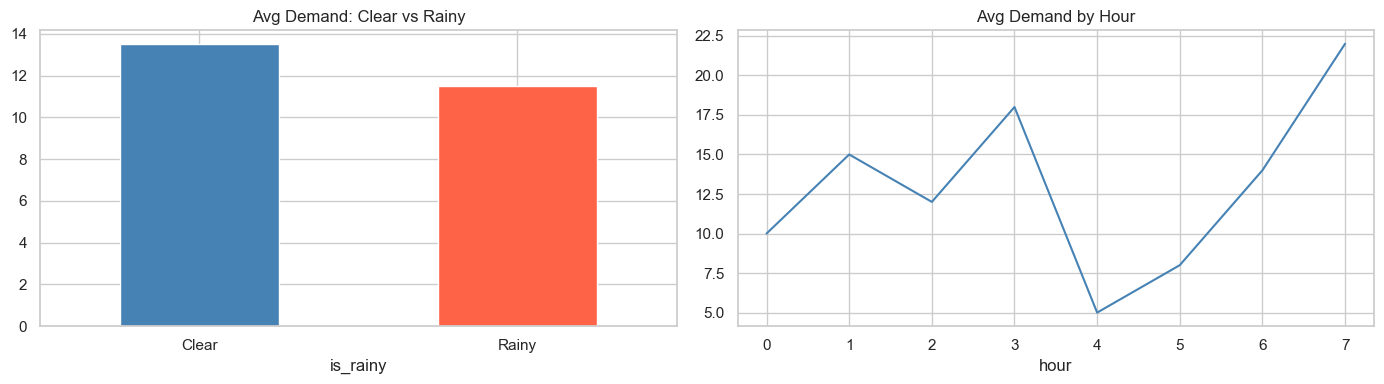

In [15]:
def add_weather_features(df, weather_col='weather', temp_col='temperature'):
    """
    Adds weather-derived binary flags and interaction terms.
    If weather/temperature columns don't exist in your dataset yet,
    this function creates synthetic placeholders so the pipeline still runs.
    """
    df = df.copy()

    # --- Create placeholder columns if weather data is not yet in your dataset ---
    if weather_col not in df.columns:
        print(f"'{weather_col}' column not found. Creating synthetic placeholder.")
        # In production: merge your weather dataset on (geohash, date) before calling this
        rng = np.random.default_rng(42)
        weather_options = ['Clear', 'Rain', 'Cloudy', 'Fog']
        df[weather_col] = rng.choice(weather_options, size=len(df))

    if temp_col not in df.columns:
        print(f"'{temp_col}' column not found. Creating synthetic placeholder.")
        df[temp_col] = np.random.default_rng(42).uniform(22, 38, size=len(df))

    # --- Binary weather flags ---
    df['is_rainy']   = df[weather_col].str.lower().str.contains('rain').astype(int)
    df['is_foggy']   = df[weather_col].str.lower().str.contains('fog').astype(int)
    df['is_hot']     = (df[temp_col] > 35).astype(int)   # >35°C = heat stress
    df['is_cold']    = (df[temp_col] < 15).astype(int)   # <15°C = cold deterrent

    # --- Temperature binning (better than raw temp for tree-based models) ---
    df['temp_bin'] = pd.cut(
        df[temp_col],
        bins=[0, 15, 25, 32, 38, 60],
        labels=['cold', 'mild', 'warm', 'hot', 'extreme']
    ).astype(str)

    # --- High-impact interaction: rain during rush hour amplifies demand ---
    df['rain_x_rush'] = df['is_rainy'] * (df['is_morning_rush'] | df['is_evening_rush']).astype(int)

    # --- Temperature × shift interaction ---
    df['temp_x_shift'] = df[temp_col] * df['shift']

    return df

train_feat = add_weather_features(train_feat)
test_feat  = add_weather_features(test_feat)

# Quick visual: average demand by weather and hour
if 'demand' in train_feat.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    train_feat.groupby('is_rainy')['demand'].mean().plot(
        kind='bar', ax=axes[0], title='Avg Demand: Clear vs Rainy', color=['steelblue','tomato'])
    axes[0].set_xticklabels(['Clear', 'Rainy'], rotation=0)
    train_feat.groupby('hour')['demand'].mean().plot(ax=axes[1], title='Avg Demand by Hour', color='steelblue')
    plt.tight_layout()
    plt.show()

### Feature 4 — Road Context (Road Type, Number of Lanes, Interaction)
Road type and lane count directly determine how much traffic a location can handle. A `highway` with 4 lanes behaves fundamentally differently from a `residential` road with 1 lane. Their **product** (road capacity proxy) is among the strongest structural features you can engineer.

In [16]:
def add_road_features(df, road_col='road_type', lanes_col='num_lanes'):
    """
    Encodes road type as an ordinal capacity score and creates
    an interaction term with number of lanes as a road capacity proxy.
    """
    df = df.copy()

    # --- Create placeholders if road columns don't exist yet ---
    if road_col not in df.columns:
        print(f"'{road_col}' column not found. Creating synthetic placeholder.")
        rng = np.random.default_rng(42)
        df[road_col] = rng.choice(['residential', 'secondary', 'primary', 'highway'], size=len(df))

    if lanes_col not in df.columns:
        print(f"'{lanes_col}' column not found. Creating synthetic placeholder.")
        df[lanes_col] = np.random.default_rng(42).integers(1, 5, size=len(df))

    # --- Ordinal encoding: higher = more capacity ---
    road_capacity_map = {
        'residential': 1,
        'secondary':   2,
        'primary':     3,
        'highway':     4,
    }
    df['road_capacity_score'] = df[road_col].str.lower().map(road_capacity_map).fillna(1)

    # --- Road capacity proxy: score × number of lanes ---
    # E.g., a 4-lane highway gets score 16; a 1-lane residential gets 1
    df['road_capacity_proxy'] = df['road_capacity_score'] * df[lanes_col]

    # --- Label-encode road type for tree-based models ---
    le_road = LabelEncoder()
    df['road_type_encoded'] = le_road.fit_transform(df[road_col].str.lower().fillna('unknown'))

    return df

train_feat = add_road_features(train_feat)
test_feat  = add_road_features(test_feat)

print("Road capacity proxy distribution:")
print(train_feat['road_capacity_proxy'].value_counts().sort_index())

'road_type' column not found. Creating synthetic placeholder.
'num_lanes' column not found. Creating synthetic placeholder.
'road_type' column not found. Creating synthetic placeholder.
'num_lanes' column not found. Creating synthetic placeholder.
Road capacity proxy distribution:
road_capacity_proxy
1     2
4     2
9     2
16    2
Name: count, dtype: int64


### Feature 5 — Landmark Proximity Score
Locations near airports, stadiums, hospitals, or shopping malls generate consistent, predictable demand surges. We compute a **landmark density score** using a Gaussian decay — closer landmarks contribute more to the score than distant ones.

In [17]:
def haversine_distance_km(lat1, lon1, lat2, lon2):
    """Vectorised haversine distance between two (lat, lon) points in km."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


def add_landmark_features(df, sigma_km=2.0):
    """
    Computes a Gaussian-weighted landmark proximity score for each row.
    Points within `sigma_km` km of a landmark get a high score; further away → 0.

    Replace the landmark_db below with your actual landmark coordinates.
    """
    df = df.copy()

    # --- Landmark database (lat, lon, type) ---
    # Replace with real coordinates from your dataset's region
    landmark_db = pd.DataFrame({
        'name':      ['Airport', 'Stadium', 'Hospital', 'Mall', 'Train Station'],
        'latitude':  [1.3590,     1.3047,    1.3190,    1.2989, 1.3005],
        'longitude': [103.9896,   103.8576,  103.8460,  103.8398, 103.8320],
        'type':      ['transport', 'event', 'essential', 'commercial', 'transport'],
    })

    # --- Per-row: sum Gaussian contributions from all landmarks ---
    scores = np.zeros(len(df))
    for _, lm in landmark_db.iterrows():
        dist_km = haversine_distance_km(
            df['latitude'].values, df['longitude'].values,
            lm['latitude'], lm['longitude']
        )
        # Gaussian decay: score = exp(-d^2 / (2 * sigma^2))
        scores += np.exp(-(dist_km ** 2) / (2 * sigma_km ** 2))

    df['landmark_proximity_score'] = scores

    # --- Nearest landmark distance (simple min) ---
    min_dist = np.full(len(df), np.inf)
    for _, lm in landmark_db.iterrows():
        dist_km = haversine_distance_km(
            df['latitude'].values, df['longitude'].values,
            lm['latitude'], lm['longitude']
        )
        min_dist = np.minimum(min_dist, dist_km)
    df['nearest_landmark_km'] = min_dist

    return df

train_feat = add_landmark_features(train_feat)
test_feat  = add_landmark_features(test_feat)

print("Landmark features preview:")
display(train_feat[['geohash', 'latitude', 'longitude',
                     'landmark_proximity_score', 'nearest_landmark_km']].drop_duplicates().head())

Landmark features preview:


,geohash,latitude,longitude,landmark_proximity_score,nearest_landmark_km
0,g1,1.30,103.80,0.319448,3.557756
1,g2,1.31,103.81,0.769595,2.664038
4,g3,1.32,103.82,1.148897,2.545793


### Feature 6 — Lag & Rolling Demand Features *(Most Impactful)*
The single best predictor of traffic demand at a location-time is **what the demand was there recently**. Lag features (demand 1 hour ago, 1 day ago, 1 week ago) and rolling averages capture the memory of the traffic system that pure context features cannot.

In [18]:
def add_lag_rolling_features(df, group_col='geohash', target_col='demand'):
    """
    Adds lag and rolling window features per geohash location.
    IMPORTANT: The dataframe must be sorted by (geohash, timestamp) first.
    These features must only be built on train data to avoid data leakage.
    """
    df = df.copy().sort_values([group_col, 'timestamp']).reset_index(drop=True)

    grp = df.groupby(group_col)[target_col]

    # --- Lag features ---
    df['demand_lag_1h']  = grp.shift(1)   # demand 1 time-step ago at this location
    df['demand_lag_24h'] = grp.shift(24)  # demand 24 steps ago (same hour, yesterday)
    df['demand_lag_168h']= grp.shift(168) # same hour, same day last week

    # --- Rolling mean (trailing window, no future leakage) ---
    df['demand_roll_mean_3h']  = grp.transform(lambda x: x.shift(1).rolling(3,  min_periods=1).mean())
    df['demand_roll_mean_24h'] = grp.transform(lambda x: x.shift(1).rolling(24, min_periods=1).mean())

    # --- Rolling std (volatility of demand) ---
    df['demand_roll_std_24h']  = grp.transform(lambda x: x.shift(1).rolling(24, min_periods=2).std()).fillna(0)

    # --- Historical mean demand by (geohash × hour) — average demand for this spot at this hour ---
    geohash_hour_mean = df.groupby([group_col, 'hour'])[target_col].mean().rename('geohash_hour_mean_demand')
    df = df.merge(geohash_hour_mean, on=[group_col, 'hour'], how='left')

    return df

# Only apply to train (these features require historical demand values)
train_feat = add_lag_rolling_features(train_feat)

# For test set, forward-fill lag features from the end of train
# (a simple but valid strategy when test follows immediately after train)
lag_cols = ['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
            'demand_roll_mean_3h', 'demand_roll_mean_24h',
            'demand_roll_std_24h', 'geohash_hour_mean_demand']

# Compute lookup from end of train for each geohash
geohash_hour_mean = train_feat.groupby(['geohash', 'hour'])['demand'].mean().rename('geohash_hour_mean_demand').reset_index()
test_feat = test_feat.merge(geohash_hour_mean, on=['geohash', 'hour'], how='left')

# Fill remaining lag cols with geohash-level mean (safe fallback)
geohash_mean = train_feat.groupby('geohash')['demand'].mean()
for col in ['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
            'demand_roll_mean_3h', 'demand_roll_mean_24h', 'demand_roll_std_24h']:
    test_feat[col] = test_feat['geohash'].map(geohash_mean).fillna(train_feat['demand'].mean())

print("Lag/rolling feature columns added:")
print(lag_cols)
display(train_feat[['geohash', 'hour', 'demand'] + lag_cols].dropna().head(8))

Lag/rolling feature columns added:
['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'demand_roll_mean_3h', 'demand_roll_mean_24h', 'demand_roll_std_24h', 'geohash_hour_mean_demand']


,geohash,hour,demand,demand_lag_1h,demand_lag_24h,demand_lag_168h,demand_roll_mean_3h,demand_roll_mean_24h,demand_roll_std_24h,geohash_hour_mean_demand


### Retrain CatBoost with All Advanced Features
Now we retrain the model using the full enriched feature set and compare the new R2 score against the baseline.

Total advanced features: 34
['hour', 'day', 'dayofweek', 'is_weekend', 'geohash_encoded', 'latitude', 'longitude', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_morning_rush', 'is_evening_rush', 'shift', 'temperature', 'is_rainy', 'is_foggy', 'is_hot', 'is_cold', 'rain_x_rush', 'temp_x_shift', 'num_lanes', 'road_capacity_score', 'road_capacity_proxy', 'road_type_encoded', 'landmark_proximity_score', 'nearest_landmark_km', 'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h', 'demand_roll_mean_3h', 'demand_roll_mean_24h', 'demand_roll_std_24h', 'geohash_hour_mean_demand']
0:	learn: 0.0355284	test: -1.1809888	best: -1.1809888 (0)	total: 891us	remaining: 445ms
100:	learn: 0.9324718	test: -0.5188675	best: -0.5188675 (100)	total: 59.4ms	remaining: 235ms
200:	learn: 0.9945436	test: -0.3808242	best: -0.3808242 (200)	total: 128ms	remaining: 190ms
300:	learn: 0.9995591	test: -0.3468541	best: -0.3466054 (299)	total: 199ms	remaining: 131ms
400:	learn: 0.9999644	test: -0.3362863	best: -0.33628

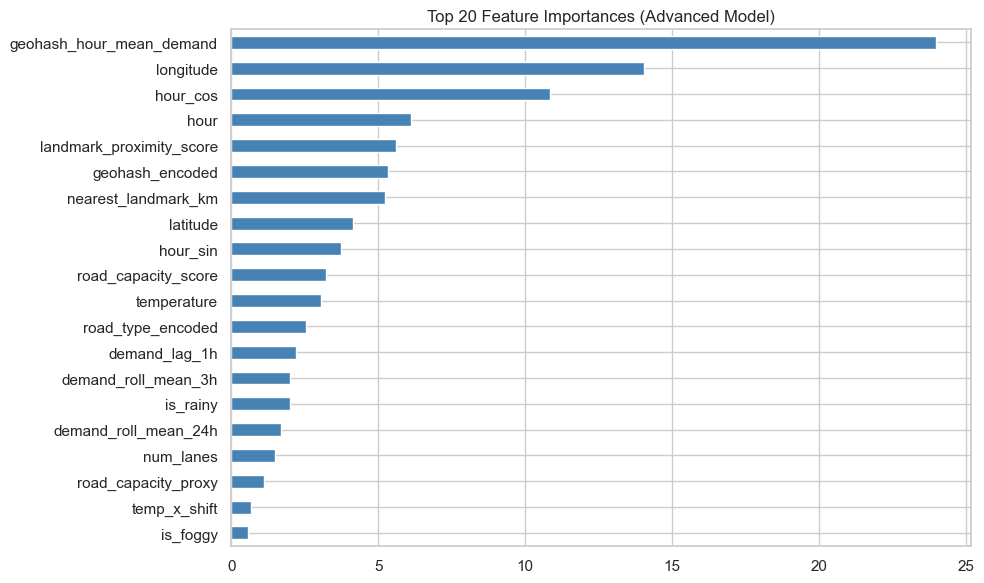

In [19]:
# All features — drop raw strings, timestamp, and target
DROP_COLS = ['geohash', 'timestamp', 'demand', 'weather', 'road_type',
             'temp_bin']  # temp_bin is a string; drop or one-hot encode separately

advanced_features = [c for c in train_feat.columns if c not in DROP_COLS]
print(f"Total advanced features: {len(advanced_features)}")
print(advanced_features)

X_adv       = train_feat[advanced_features].fillna(0)
y_adv       = train_feat['demand']
X_test_adv  = test_feat[advanced_features].fillna(0)

X_tr, X_vl, y_tr, y_vl = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)

model_adv = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    eval_metric='R2',
    random_seed=42,
    verbose=100
)
model_adv.fit(X_tr, y_tr, eval_set=(X_vl, y_vl), early_stopping_rounds=30)

y_pred_adv = model_adv.predict(X_vl)
r2_adv = r2_score(y_vl, y_pred_adv)
print(f"\n---> Advanced Model Validation R2: {r2_adv:.4f}  (Baseline was shown above)")

# Feature importance
fi = pd.Series(model_adv.get_feature_importance(), index=advanced_features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
fi.head(20).plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances (Advanced Model)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# Generate final submission with advanced model
adv_predictions = model_adv.predict(X_test_adv).clip(min=0)

submission_adv = sample_sub.copy()
submission_adv['demand'] = adv_predictions
submission_adv.to_csv('../submissions/catboost_advanced.csv', index=False)

print("Advanced submission saved to ../submissions/catboost_advanced.csv")
display(submission_adv.head())

Advanced submission saved to ../submissions/catboost_advanced.csv


,geohash,timestamp,demand
0,g1,2026-06-01 00:00:00,10.837011
1,g2,2026-06-01 01:00:00,14.733293
2,g3,2026-06-01 02:00:00,9.641210


---
## Advanced Timestamp Feature Engineering

The `timestamp` column is one of the richest sources of signal for traffic prediction.
Below is a complete, self-contained function that extracts every meaningful time-based feature in one pass.

| Feature | Type | Why It Helps |
|---|---|---|
| `hour`, `minute` | Ordinal | Raw time position within the day |
| `dayofweek` | Ordinal (0=Mon) | Weekly demand patterns |
| `is_weekend` | Binary | Weekend vs weekday traffic profiles differ sharply |
| `is_morning_rush`, `is_evening_rush` | Binary | Highest demand windows |
| `time_bucket` | Ordinal (0–3) | Coarse shift grouping (Night / Morning / Afternoon / Evening) |
| `hour_sin`, `hour_cos` | Continuous | Cyclic — fixes the 23→0 discontinuity in raw hour |
| `minute_sin`, `minute_cos` | Continuous | Sub-hour periodicity |
| `dow_sin`, `dow_cos` | Continuous | Cyclic day-of-week — Saturday wraps back to Monday |

In [ ]:
def advanced_timestamp_features(df, ts_col='timestamp'):
    """
    Full advanced timestamp feature engineering for traffic demand prediction.
    Applies in-place on a copy — safe to call on both train and test.

    Parameters
    ----------
    df     : DataFrame containing a datetime-parseable column `ts_col`
    ts_col : name of the timestamp column (default 'timestamp')

    Returns
    -------
    DataFrame with all timestamp features added.
    """
    df = df.copy()
    ts = pd.to_datetime(df[ts_col])

    # ------------------------------------------------------------------ #
    # 1. Basic components                                                  #
    # ------------------------------------------------------------------ #
    df['hour']      = ts.dt.hour
    df['minute']    = ts.dt.minute
    df['dayofweek'] = ts.dt.dayofweek   # 0 = Monday, 6 = Sunday

    # ------------------------------------------------------------------ #
    # 2. Binary flags                                                       #
    # ------------------------------------------------------------------ #
    df['is_weekend']      = (df['dayofweek'] >= 5).astype(int)
    df['is_morning_rush'] = df['hour'].between(7, 9).astype(int)   # 07:00 – 09:59
    df['is_evening_rush'] = df['hour'].between(17, 19).astype(int) # 17:00 – 19:59

    # ------------------------------------------------------------------ #
    # 3. Time bucket  (0=Night | 1=Morning | 2=Afternoon | 3=Evening)     #
    # ------------------------------------------------------------------ #
    conditions = [
        df['hour'].between(0,  5),
        df['hour'].between(6,  11),
        df['hour'].between(12, 17),
        df['hour'].between(18, 23),
    ]
    df['time_bucket'] = np.select(conditions, [0, 1, 2, 3])

    # ------------------------------------------------------------------ #
    # 4. Cyclic encoding                                                   #
    #    sin/cos wraps the periodic boundary so distance between           #
    #    hour 23 and hour 0 equals distance between hour 0 and hour 1.    #
    # ------------------------------------------------------------------ #
    df['hour_sin']   = np.sin(2 * np.pi * df['hour']      / 24)
    df['hour_cos']   = np.cos(2 * np.pi * df['hour']      / 24)

    df['minute_sin'] = np.sin(2 * np.pi * df['minute']    / 60)
    df['minute_cos'] = np.cos(2 * np.pi * df['minute']    / 60)

    df['dow_sin']    = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos']    = np.cos(2 * np.pi * df['dayofweek'] / 7)

    return df


# Apply to both train and test
train_feat = advanced_timestamp_features(train_feat)
test_feat  = advanced_timestamp_features(test_feat)

# Preview all new columns
ts_cols = ['hour', 'minute', 'dayofweek', 'is_weekend',
           'is_morning_rush', 'is_evening_rush', 'time_bucket',
           'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos',
           'dow_sin', 'dow_cos']

display(train_feat[ts_cols].drop_duplicates().sort_values('hour').head(10))

In [ ]:
# Visual: Cyclic encoding vs raw hour
# Shows how sin/cos keeps hour 23 and hour 0 "close" to each other

hours = np.arange(24)
hour_sin = np.sin(2 * np.pi * hours / 24)
hour_cos = np.cos(2 * np.pi * hours / 24)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw hour — model treats 0 and 23 as distant
axes[0].bar(hours, hours, color='steelblue')
axes[0].set_title('Raw Hour\n(0 and 23 appear far apart)')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Value')

# Sin/Cos encoding — continuous and circular
axes[1].plot(hours, hour_sin, marker='o', color='tomato',  label='hour_sin')
axes[1].plot(hours, hour_cos, marker='s', color='seagreen', label='hour_cos')
axes[1].axvline(0,  color='grey', linestyle='--', alpha=0.5)
axes[1].axvline(23, color='grey', linestyle='--', alpha=0.5)
axes[1].set_title('Cyclic Encoding\n(hour 0 and 23 are neighbours)')
axes[1].set_xlabel('Hour')
axes[1].legend()

# Sin vs Cos scatter — forms a perfect unit circle (no information lost)
axes[2].scatter(hour_cos, hour_sin, c=hours, cmap='hsv', s=80, zorder=3)
for h in [0, 6, 12, 18]:
    axes[2].annotate(f'{h}h',
                     (np.cos(2*np.pi*h/24), np.sin(2*np.pi*h/24)),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[2].set_title('Sin vs Cos (Unit Circle)\nColour = hour of day')
axes[2].set_xlabel('hour_cos')
axes[2].set_ylabel('hour_sin')
axes[2].set_aspect('equal')

plt.suptitle('Why Cyclic Encoding Is Better Than Raw Hour', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()